In [1]:
from sklearn.datasets import load_iris
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import math

In [2]:
iris = load_iris()
iris_data = iris.data
iris_data_pd = pd.DataFrame(iris_data, columns=iris.feature_names)
iris_data_pd

,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm)
0,5.1,3.5,1.4,0.2
1,4.9,3.0,1.4,0.2
2,4.7,3.2,1.3,0.2
3,4.6,3.1,1.5,0.2
4,5.0,3.6,1.4,0.2
...,...,...,...,...
145,6.7,3.0,5.2,2.3
146,6.3,2.5,5.0,1.9
147,6.5,3.0,5.2,2.0
148,6.2,3.4,5.4,2.3


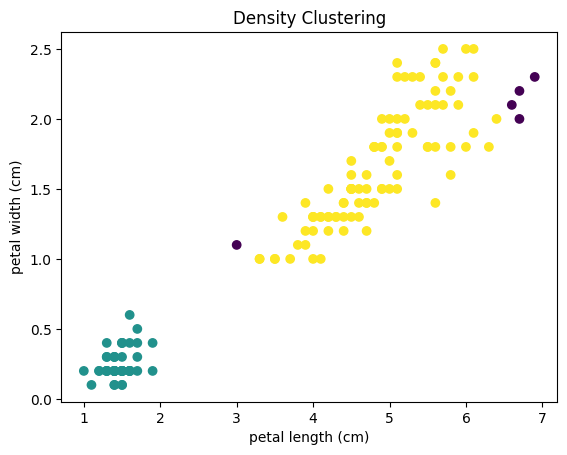

In [3]:
from sklearn.cluster import DBSCAN

## eps : cluster 반경의 반지름을 의미 
db = DBSCAN(eps=0.5, min_samples=10)
db.fit(iris_data_pd.iloc[:, 2:4])
y_pred = db.fit_predict(iris_data_pd.iloc[:, 2:4])
plt.scatter(iris_data_pd.iloc[:, 2], iris_data_pd.iloc[:, 3], c=y_pred)
plt.title('Density Clustering')
plt.xlabel('petal length (cm)')
plt.ylabel('petal width (cm)')
plt.show()

In [4]:
db.labels_

array([ 0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,
        0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,
        0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  1,
        1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,
        1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,
        1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1, -1,  1,  1,  1,
        1,  1,  1, -1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1, -1, -1,
        1,  1,  1, -1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,
        1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1],
      dtype=int64)

#### -> -1의 경우 노이즈 데이터를 의미

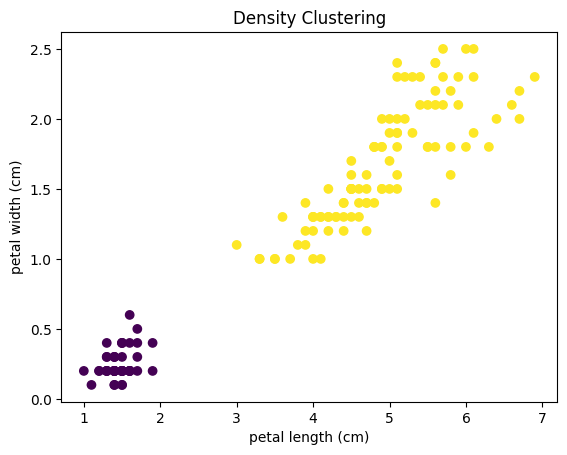

In [5]:
from sklearn.cluster import DBSCAN

db = DBSCAN(eps=0.5, min_samples=5)
db.fit(iris_data_pd.iloc[:, 2:4])
y_pred = db.fit_predict(iris_data_pd.iloc[:, 2:4])
plt.scatter(iris_data_pd.iloc[:, 2], iris_data_pd.iloc[:, 3], c=y_pred)
plt.title('Density Clustering')
plt.xlabel('petal length (cm)')
plt.ylabel('petal width (cm)')
plt.show()

min_samples: 2 eps: 1.000000  cluster: [-1  0  0 -1  0 -1  1  1  0  1 -1 -1]
min_samples: 2 eps: 1.500000  cluster: [0 1 1 1 1 0 2 2 1 2 2 0]
min_samples: 2 eps: 2.000000  cluster: [0 1 1 1 1 0 0 0 1 0 0 0]
min_samples: 2 eps: 3.000000  cluster: [0 0 0 0 0 0 0 0 0 0 0 0]
min_samples: 3 eps: 1.000000  cluster: [-1  0  0 -1  0 -1  1  1  0  1 -1 -1]
min_samples: 3 eps: 1.500000  cluster: [0 1 1 1 1 0 2 2 1 2 2 0]
min_samples: 3 eps: 2.000000  cluster: [0 1 1 1 1 0 0 0 1 0 0 0]
min_samples: 3 eps: 3.000000  cluster: [0 0 0 0 0 0 0 0 0 0 0 0]
min_samples: 5 eps: 1.000000  cluster: [-1 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1]
min_samples: 5 eps: 1.500000  cluster: [-1  0  0  0  0 -1 -1 -1  0 -1 -1 -1]
min_samples: 5 eps: 2.000000  cluster: [-1  0  0  0  0 -1 -1 -1  0 -1 -1 -1]
min_samples: 5 eps: 3.000000  cluster: [0 0 0 0 0 0 0 0 0 0 0 0]


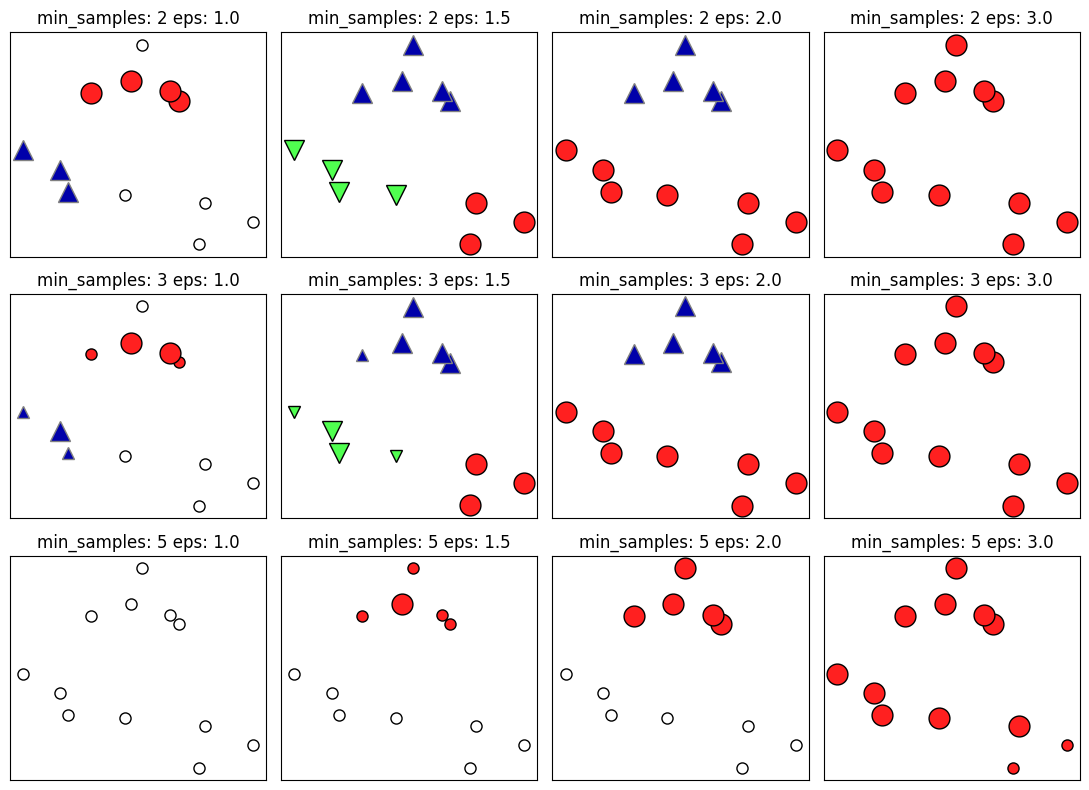

In [6]:
import mglearn   # pip install mglearn

mglearn.plots.plot_dbscan()

### [실전 예제]

#### 얼굴 데이터 셋

In [7]:
from sklearn.datasets import fetch_lfw_people
from sklearn.decomposition import PCA
import numpy as np

In [9]:
people = fetch_lfw_people(min_faces_per_person=20, resize=0.7)
print(people.images.shape)
print(people.data.shape)
image_shape = people.images[0].shape
print(image_shape)

(3023, 87, 65)
(3023, 5655)
(87, 65)


In [10]:
people.keys()

dict_keys(['data', 'images', 'target', 'target_names', 'DESCR'])

In [11]:
people.data.shape

(3023, 5655)

In [12]:
people.images.shape

(3023, 87, 65)

In [13]:
people.target_names

array(['Alejandro Toledo', 'Alvaro Uribe', 'Amelie Mauresmo',
       'Andre Agassi', 'Angelina Jolie', 'Ariel Sharon',
       'Arnold Schwarzenegger', 'Atal Bihari Vajpayee', 'Bill Clinton',
       'Carlos Menem', 'Colin Powell', 'David Beckham', 'Donald Rumsfeld',
       'George Robertson', 'George W Bush', 'Gerhard Schroeder',
       'Gloria Macapagal Arroyo', 'Gray Davis', 'Guillermo Coria',
       'Hamid Karzai', 'Hans Blix', 'Hugo Chavez', 'Igor Ivanov',
       'Jack Straw', 'Jacques Chirac', 'Jean Chretien',
       'Jennifer Aniston', 'Jennifer Capriati', 'Jennifer Lopez',
       'Jeremy Greenstock', 'Jiang Zemin', 'John Ashcroft',
       'John Negroponte', 'Jose Maria Aznar', 'Juan Carlos Ferrero',
       'Junichiro Koizumi', 'Kofi Annan', 'Laura Bush',
       'Lindsay Davenport', 'Lleyton Hewitt', 'Luiz Inacio Lula da Silva',
       'Mahmoud Abbas', 'Megawati Sukarnoputri', 'Michael Bloomberg',
       'Naomi Watts', 'Nestor Kirchner', 'Paul Bremer', 'Pete Sampras',
       'Rece

In [14]:
people.target

array([61, 25,  9, ..., 14, 15, 14], dtype=int64)

In [15]:
print(people.DESCR)

.. _labeled_faces_in_the_wild_dataset:

The Labeled Faces in the Wild face recognition dataset
------------------------------------------------------

This dataset is a collection of JPEG pictures of famous people collected
over the internet, and the details are available on the Kaggle website:

https://www.kaggle.com/datasets/jessicali9530/lfw-dataset

Each picture is centered on a single face. The typical task is called
Face Verification: given a pair of two pictures, a binary classifier
must predict whether the two images are from the same person.

An alternative task, Face Recognition or Face Identification is:
given the picture of the face of an unknown person, identify the name
of the person by referring to a gallery of previously seen pictures of
identified persons.

Both Face Verification and Face Recognition are tasks that are typically
performed on the output of a model trained to perform Face Detection. The
most popular model for Face Detection is called Viola-Jones and is
i

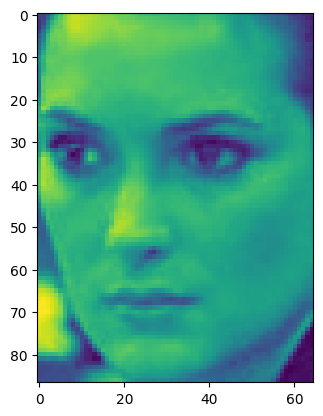

In [16]:
from matplotlib import pyplot as plt

plt.imshow(people.images[0])

In [17]:
x, cnt = np.unique(people.target, return_counts=True)
print(x)
print(cnt)

[ 0  1  2  3  4  5  6  7  8  9 10 11 12 13 14 15 16 17 18 19 20 21 22 23
 24 25 26 27 28 29 30 31 32 33 34 35 36 37 38 39 40 41 42 43 44 45 46 47
 48 49 50 51 52 53 54 55 56 57 58 59 60 61]
[ 39  35  21  36  20  77  42  24  29  21 236  31 121  22 530 109  44  26
  30  22  39  71  20  28  52  55  21  42  21  24  20  53  31  23  28  60
  32  41  22  41  48  29  33  20  22  37  20  22  30  27  32  26  23  52
  33  23  25  33 144  32  49  24]


In [18]:
mask = np.zeros(people.target.shape, dtype=np.bool_)
print(mask.shape)
mask[0:100]

(3023,)


array([False, False, False, False, False, False, False, False, False,
       False, False, False, False, False, False, False, False, False,
       False, False, False, False, False, False, False, False, False,
       False, False, False, False, False, False, False, False, False,
       False, False, False, False, False, False, False, False, False,
       False, False, False, False, False, False, False, False, False,
       False, False, False, False, False, False, False, False, False,
       False, False, False, False, False, False, False, False, False,
       False, False, False, False, False, False, False, False, False,
       False, False, False, False, False, False, False, False, False,
       False, False, False, False, False, False, False, False, False,
       False])

In [20]:
for target in np.unique(people.target):
    print(target)
    mask[np.where(people.target == target)[0][:50]] = 1
    print(np.where(people.target == target))

0
(array([  58,   72,   90,  314,  494,  496,  598,  650,  960, 1078, 1212,
       1243, 1265, 1356, 1497, 1586, 1622, 1793, 1803, 1816, 1881, 1952,
       1962, 2003, 2068, 2179, 2183, 2239, 2373, 2441, 2510, 2535, 2622,
       2649, 2651, 2697, 2819, 2960, 2998], dtype=int64),)
1
(array([   4,   17,   41,   87,  142,  216,  333,  413,  417,  508,  857,
        876,  940,  944,  949, 1165, 1307, 1505, 1529, 1539, 1729, 1807,
       1837, 1933, 2211, 2243, 2254, 2269, 2285, 2290, 2360, 2387, 2616,
       2636, 2926], dtype=int64),)
2
(array([  65,  188,  266,  509,  912, 1055, 1102, 1353, 1379, 1468, 1868,
       1924, 2073, 2115, 2180, 2272, 2344, 2412, 2444, 2492, 2531],
      dtype=int64),)
3
(array([  27,  237,  388,  449,  461,  612,  623,  676,  738,  770, 1106,
       1132, 1187, 1270, 1273, 1280, 1710, 1714, 1752, 1942, 2056, 2074,
       2160, 2176, 2206, 2216, 2255, 2527, 2601, 2608, 2675, 2738, 2742,
       2801, 2876, 3010], dtype=int64),)
4
(array([  43,   74,  133,  221, 

In [22]:
X_people = people.data[mask]
y_people = people.target[mask]

In [23]:
X_people.shape, y_people.shape

((2063, 5655), (2063,))

In [24]:
x, cnt = np.unique(y_people, return_counts=True)
print(x)
print(cnt)

[ 0  1  2  3  4  5  6  7  8  9 10 11 12 13 14 15 16 17 18 19 20 21 22 23
 24 25 26 27 28 29 30 31 32 33 34 35 36 37 38 39 40 41 42 43 44 45 46 47
 48 49 50 51 52 53 54 55 56 57 58 59 60 61]
[39 35 21 36 20 50 42 24 29 21 50 31 50 22 50 50 44 26 30 22 39 50 20 28
 50 50 21 42 21 24 20 50 31 23 28 50 32 41 22 41 48 29 33 20 22 37 20 22
 30 27 32 26 23 50 33 23 25 33 50 32 49 24]


In [25]:
X_people = X_people / 255.   # MinMaxScaler

In [26]:
X_people.shape

(2063, 5655)

In [27]:
pca = PCA(n_components=100, whiten=True, random_state=0)
pca.fit(X_people)
X_pca = pca.transform(X_people)
print(X_pca.shape)

(2063, 100)


In [28]:
from sklearn.cluster import DBSCAN

dbscan = DBSCAN()
labels = dbscan.fit_predict(X_pca)
print('고유한 레이블 \n{}'.format(np.unique(labels)))

고유한 레이블 
[-1]


In [29]:
dbscan = DBSCAN(min_samples=3)
labels = dbscan.fit_predict(X_pca)
print('고유한 레이블 \n{}'.format(np.unique(labels)))

고유한 레이블 
[-1]


In [31]:
dbscan = DBSCAN(min_samples=3, eps=15)
labels = dbscan.fit_predict(X_pca)
print('고유한 레이블 \n{}'.format(np.unique(labels)))

고유한 레이블 
[-1  0]


In [32]:
print("클러스터 별 포인트 수: {}".format(np.bincount(labels + 1)))

클러스터 별 포인트 수: [  37 2026]


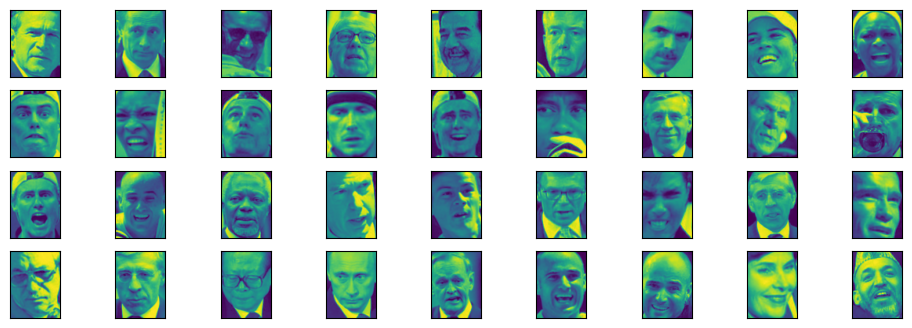

In [35]:
import matplotlib.pyplot as plt

noise = X_people[labels == -1]
fig, axes = plt.subplots(4, 9, subplot_kw={'xticks':(), 'yticks':()}, figsize=(12,4))
for image, ax in zip(noise, axes.ravel()):
    ax.imshow(image.reshape(image_shape))

In [38]:
for eps in [1, 3, 5, 7, 9, 11, 13]:
    for min_samples in [3, 5, 7, 9]:
        print('\neps = {}, min_samples = {}'.format(eps, min_samples))
        dbscan = DBSCAN(eps=eps, min_samples=min_samples)
        labels = dbscan.fit_predict(X_pca)
        print('클러스터 값 {}'.format(np.unique(labels)))
        print('클러스터 수 {}'.format(len(np.unique(labels))))
        print('클러스터 크기 {}'.format(np.unique(labels)+1))


eps = 1, min_samples = 3
클러스터 값 [-1]
클러스터 수 1
클러스터 크기 [0]

eps = 1, min_samples = 5
클러스터 값 [-1]
클러스터 수 1
클러스터 크기 [0]

eps = 1, min_samples = 7
클러스터 값 [-1]
클러스터 수 1
클러스터 크기 [0]

eps = 1, min_samples = 9
클러스터 값 [-1]
클러스터 수 1
클러스터 크기 [0]

eps = 3, min_samples = 3
클러스터 값 [-1]
클러스터 수 1
클러스터 크기 [0]

eps = 3, min_samples = 5
클러스터 값 [-1]
클러스터 수 1
클러스터 크기 [0]

eps = 3, min_samples = 7
클러스터 값 [-1]
클러스터 수 1
클러스터 크기 [0]

eps = 3, min_samples = 9
클러스터 값 [-1]
클러스터 수 1
클러스터 크기 [0]

eps = 5, min_samples = 3
클러스터 값 [-1  0]
클러스터 수 2
클러스터 크기 [0 1]

eps = 5, min_samples = 5
클러스터 값 [-1]
클러스터 수 1
클러스터 크기 [0]

eps = 5, min_samples = 7
클러스터 값 [-1]
클러스터 수 1
클러스터 크기 [0]

eps = 5, min_samples = 9
클러스터 값 [-1]
클러스터 수 1
클러스터 크기 [0]

eps = 7, min_samples = 3
클러스터 값 [-1  0  1  2  3  4  5  6]
클러스터 수 8
클러스터 크기 [0 1 2 3 4 5 6 7]

eps = 7, min_samples = 5
클러스터 값 [-1  0  1]
클러스터 수 3
클러스터 크기 [0 1 2]

eps = 7, min_samples = 7
클러스터 값 [-1  0  1]
클러스터 수 3
클러스터 크기 [0 1 2]

eps = 7, min_samples = 9
클러스터 값 [-1  0]
클러스터 수 2
클러스터 

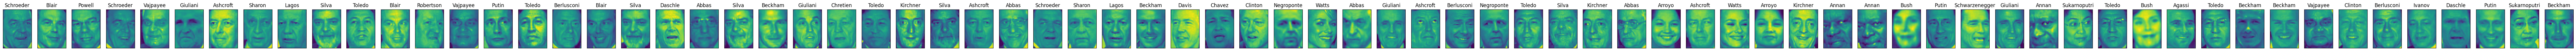

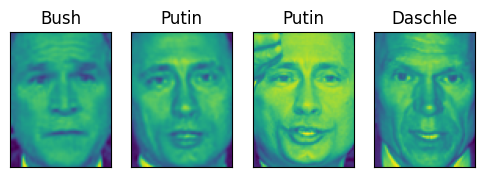

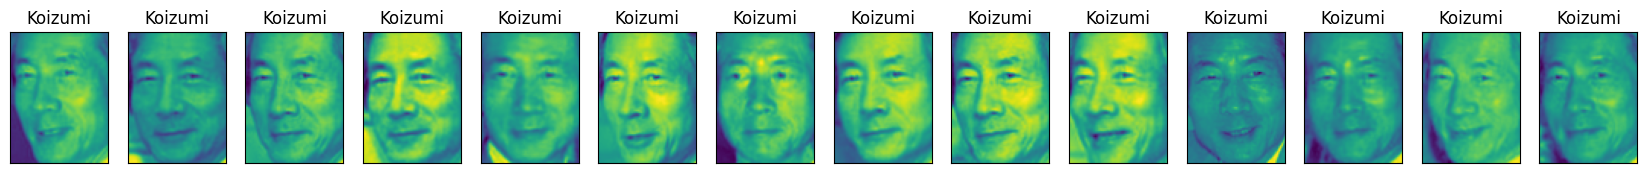

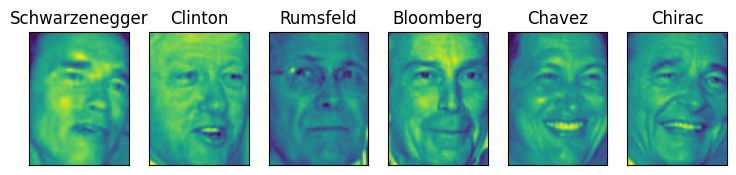

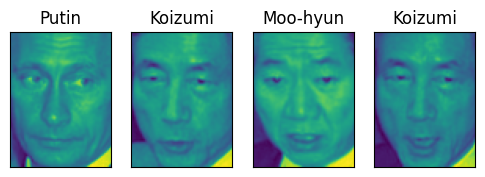

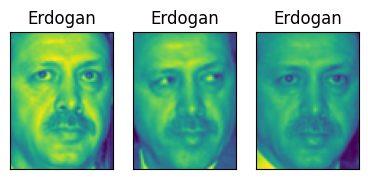

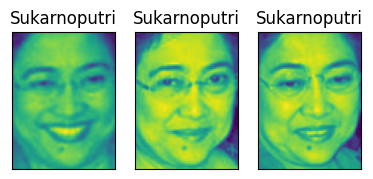

In [41]:
dbscan = DBSCAN(min_samples=3, eps=7)
labels = dbscan.fit_predict(X_pca)

for cluster in range(max(labels) + 1):
    mask = labels == cluster
    n_images = np.sum(mask)
    fog, axes = plt.subplots(1, n_images, figsize=(n_images*1.5, 4),
                           subplot_kw={'xticks':(), 'yticks':()})
    for image, label, ax in zip(X_people[mask], y_people[mask], axes):
        ax.imshow(image.reshape(image_shape))
        ax.set_title(people.target_names[label].split()[-1])